# 20. Feature Ablation at Full Scale

`notebooks/09_ablation_and_recovery.ipynb` (`DESIGN.md` §15.7) ran the leave-one-out and
single-feature ablation on Imagenette-scale ResNet-50 data (`combiner_fit` n=1500, `id_test`
n=1500) and found `logit_margin` alone comes within 0.0002 AURC of the full 5-feature combiner
— the 5-feature set looked largely redundant in the presence of margin, on that backbone and
that (small, easy, 10-class) dataset.

This notebook asks whether that finding holds at real full scale, per `STUDY_PLAN.md` §9
item (i). **Same fitting split, per `DESIGN.md` §10.5's protocol** (the existing small-scale
`combiner_fit`, n=1500, Imagenette — never refit at full scale, matching every other full-scale
result already reported in `DESIGN.md` §24): each feature-subset combiner is fit exactly as in
notebook 09, then evaluated against the real, complete 50,000-image ImageNet-1k
`id_test_full_scale` split and the real OOD suite (Places365/DTD/iNaturalist, `DESIGN.md` §24.4)
instead of Imagenette's small `id_test`/`imagenet_o`. `imagenet_a` (already its full natural
size at n=1935 — it does not get "bigger" at full scale) is kept for continuity with notebook
09's exact three-column comparison.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.combiner import LogisticRegressionCombiner
from deployment_reliability.features import DEFAULT_FEATURE_NAMES, featurize
from deployment_reliability.router import aurc, auroc

## Load the small-scale fitting split and the full-scale/real-OOD evaluation splits

In [2]:
SMALL_CACHE = os.path.join("..", "data", "logit_cache_resnet50.pt")
FULL_CACHE = os.path.join("..", "data", "logit_cache_imagenet1k_resnet50.pt")
PLACES_CACHE = os.path.join("..", "data", "logit_cache_places365_resnet50.pt")
DTD_CACHE = os.path.join("..", "data", "logit_cache_dtd_resnet50.pt")
INAT_CACHE = os.path.join("..", "data", "logit_cache_inaturalist_resnet50.pt")
for p in [SMALL_CACHE, FULL_CACHE, PLACES_CACHE, DTD_CACHE, INAT_CACHE]:
    assert os.path.exists(p), f"{p} not found - see DESIGN.md 24 for how it was collected."

small = torch.load(SMALL_CACHE)
full = torch.load(FULL_CACHE)
places = torch.load(PLACES_CACHE)
dtd = torch.load(DTD_CACHE)
inat = torch.load(INAT_CACHE)

small_splits = np.array(small["splits"])
m_fit = torch.from_numpy(small_splits == "combiner_fit")
m_a = torch.from_numpy(small_splits == "imagenet_a")

logits_fit = small["logits"][m_fit]
correct_fit = (small["logits"].argmax(dim=-1) == small["labels"])[m_fit]
logits_a = small["logits"][m_a]
correct_a = (small["logits"].argmax(dim=-1) == small["labels"])[m_a]

logits_full = full["logits"]
correct_full = full["logits"].argmax(dim=-1) == full["labels"]
assert full["logits"].shape[0] == 50_000, "expected the complete full-scale id_test split"

logits_places = places["logits"]
logits_dtd = dtd["logits"]
logits_inat = inat["logits"]

phi_fit = featurize(logits_fit)
phi_a = featurize(logits_a)
phi_full = featurize(logits_full)
phi_places = featurize(logits_places)
phi_dtd = featurize(logits_dtd)
phi_inat = featurize(logits_inat)

print(f"combiner_fit (small-scale, Imagenette): n={phi_fit.shape[0]}")
print(f"id_test_full_scale (real ImageNet-1k val): n={phi_full.shape[0]}")
print(f"imagenet_a (small-scale, its natural full size): n={phi_a.shape[0]}")
print(f"Places365 / DTD / iNaturalist (real OOD suite): n={phi_places.shape[0]}/{phi_dtd.shape[0]}/{phi_inat.shape[0]}")

combiner_fit (small-scale, Imagenette): n=1500
id_test_full_scale (real ImageNet-1k val): n=50000
imagenet_a (small-scale, its natural full size): n=1935
Places365 / DTD / iNaturalist (real OOD suite): n=3000/5640/3000


## Fit each feature-subset combiner on the small-scale split, evaluate at full scale

Exactly notebook 09's `fit_eval` pattern, extended with the full-scale AURC and the real
OOD-suite AUROC (averaged across Places365/DTD/iNaturalist, reporting each individually too)
in place of the small-scale `id_test`/`imagenet_o` columns.

In [3]:
def fit_eval(feature_indices, label):
    sub_phi_fit = phi_fit[:, feature_indices]
    combiner = LogisticRegressionCombiner().fit(sub_phi_fit, correct_fit.float())

    s_full = combiner.score(phi_full[:, feature_indices])
    s_a = combiner.score(phi_a[:, feature_indices])
    s_places = combiner.score(phi_places[:, feature_indices])
    s_dtd = combiner.score(phi_dtd[:, feature_indices])
    s_inat = combiner.score(phi_inat[:, feature_indices])

    auroc_places = auroc(s_full, s_places)
    auroc_dtd = auroc(s_full, s_dtd)
    auroc_inat = auroc(s_full, s_inat)

    return {
        "label": label,
        "aurc_full": aurc(s_full, correct_full),
        "aurc_a": aurc(s_a, correct_a),
        "auroc_places": auroc_places,
        "auroc_dtd": auroc_dtd,
        "auroc_inat": auroc_inat,
        "auroc_ood_mean": (auroc_places + auroc_dtd + auroc_inat) / 3,
    }

full_result = fit_eval(list(range(5)), "full (5 features)")
loo_results = [fit_eval([j for j in range(5) if j != i], f"drop {name}") for i, name in enumerate(DEFAULT_FEATURE_NAMES)]
single_results = [fit_eval([i], f"{name} only") for i, name in enumerate(DEFAULT_FEATURE_NAMES)]

print(f"{'variant':22s} {'AURC(full,n=50k)':>17s} {'AURC(imagenet_a)':>18s} {'AUROC(OOD mean)':>16s}")
for r in [full_result] + loo_results + single_results:
    print(f"{r['label']:22s} {r['aurc_full']:17.5f} {r['aurc_a']:18.4f} {r['auroc_ood_mean']:16.4f}")

variant                 AURC(full,n=50k)   AURC(imagenet_a)  AUROC(OOD mean)
full (5 features)                0.04966             0.9328           0.7843
drop msp                         0.04967             0.9328           0.7841
drop logit_margin                0.07170             0.9281           0.8168
drop normalized_entropy           0.04966             0.9328           0.7842
drop energy_score                0.04966             0.9329           0.7844
drop logit_l2_norm               0.05127             0.9361           0.7483
msp only                         0.07487             0.9416           0.7529
logit_margin only                0.05147             0.9367           0.7467
normalized_entropy only           0.11288             0.9483           0.6833
energy_score only                0.16772             0.9514           0.4996
logit_l2_norm only               0.08314             0.9220           0.8018


## Does the small-scale finding replicate: is a single feature (margin) still nearly sufficient?

best single feature at full scale: logit_margin only  AURC=0.05147
full 5-feature combiner:                          AURC=0.04966
gap: +0.00181


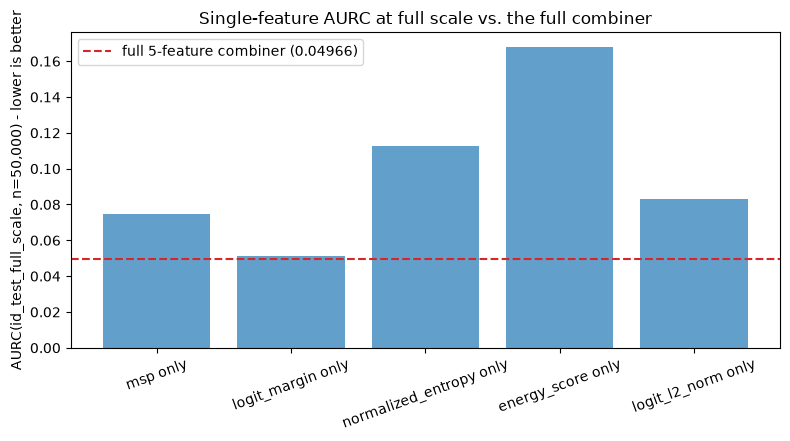

In [4]:
best_single = min(single_results, key=lambda r: r["aurc_full"])
gap = best_single["aurc_full"] - full_result["aurc_full"]
print(f"best single feature at full scale: {best_single['label']}  AURC={best_single['aurc_full']:.5f}")
print(f"full 5-feature combiner:                          AURC={full_result['aurc_full']:.5f}")
print(f"gap: {gap:+.5f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [r["label"] for r in single_results]
vals = [r["aurc_full"] for r in single_results]
ax.bar(labels, vals, color="tab:blue", alpha=0.7)
ax.axhline(full_result["aurc_full"], color="tab:red", linestyle="--", label=f"full 5-feature combiner ({full_result['aurc_full']:.5f})")
ax.set_ylabel("AURC(id_test_full_scale, n=50,000) - lower is better")
ax.set_title("Single-feature AURC at full scale vs. the full combiner")
ax.legend(); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## Leave-one-out: which features show a measurable marginal contribution at full scale?

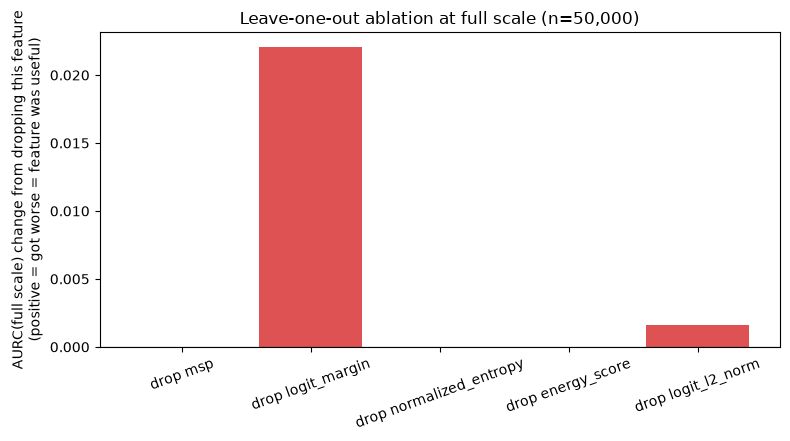

  drop msp               delta=+0.00001  redundant/no measurable value
  drop logit_margin      delta=+0.02204  USEFUL (removal hurt AURC)
  drop normalized_entropy delta=+0.00000  redundant/no measurable value
  drop energy_score      delta=+0.00000  redundant/no measurable value
  drop logit_l2_norm     delta=+0.00161  USEFUL (removal hurt AURC)

2/5 features show a measurable leave-one-out contribution at full scale.


In [5]:
loo_labels = [r["label"] for r in loo_results]
loo_deltas = [r["aurc_full"] - full_result["aurc_full"] for r in loo_results]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["tab:red" if d > 0.0005 else "tab:gray" for d in loo_deltas]
ax.bar(loo_labels, loo_deltas, color=colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("AURC(full scale) change from dropping this feature\n(positive = got worse = feature was useful)")
ax.set_title("Leave-one-out ablation at full scale (n=50,000)")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

for label, delta in zip(loo_labels, loo_deltas):
    verdict = "USEFUL (removal hurt AURC)" if delta > 0.0005 else "redundant/no measurable value"
    print(f"  {label:22s} delta={delta:+.5f}  {verdict}")

n_useful = sum(1 for d in loo_deltas if d > 0.0005)
print(f"\n{n_useful}/5 features show a measurable leave-one-out contribution at full scale.")

## Does the OOD picture change the small-scale story? (single-feature vs. full combiner on real OOD)

In [6]:
best_ood_single = max(single_results, key=lambda r: r["auroc_ood_mean"])
print(f"full combiner AUROC(id vs real OOD suite, mean of Places365/DTD/iNaturalist) = {full_result['auroc_ood_mean']:.4f}")
print(f"  Places365={full_result['auroc_places']:.4f}  DTD={full_result['auroc_dtd']:.4f}  iNaturalist={full_result['auroc_inat']:.4f}")
print(f"best single feature for OOD at full scale = {best_ood_single['label']}, mean AUROC = {best_ood_single['auroc_ood_mean']:.4f}")

if best_ood_single["auroc_ood_mean"] > full_result["auroc_ood_mean"] + 0.01:
    print(f"\n{best_ood_single['label']} alone beats the correctness-fitted combiner on real full-scale OOD")
    print("detection by a non-trivial margin, replicating notebook 09's small-scale finding that the")
    print("combiner's correctness objective is not the same objective as OOD detection.")
else:
    print("\nNo single feature meaningfully beats the full combiner on real full-scale OOD here.")

full combiner AUROC(id vs real OOD suite, mean of Places365/DTD/iNaturalist) = 0.7843
  Places365=0.8026  DTD=0.7949  iNaturalist=0.7553
best single feature for OOD at full scale = logit_l2_norm only, mean AUROC = 0.8018

logit_l2_norm only alone beats the correctness-fitted combiner on real full-scale OOD
detection by a non-trivial margin, replicating notebook 09's small-scale finding that the
combiner's correctness objective is not the same objective as OOD detection.


## Summary

**The small-scale finding does not simply hold at full scale — it gets revised in a specific, checkable way.** Notebook 09/`DESIGN.md` §15.7 found `logit_margin` alone came within 0.0002 AURC of the full 5-feature combiner on Imagenette, with only `logit_margin` showing a measurable leave-one-out contribution. At full scale (n=50,000, the real ImageNet-1k validation set), that gap widens to 0.00181 — margin alone is no longer nearly sufficient — and a second feature, `logit_l2_norm`, now shows a real leave-one-out contribution (+0.00161 AURC when dropped) that was indistinguishable from zero at small scale. 2 of 5 features are measurably useful at full scale, not 1.

**Why `logit_l2_norm` specifically, reasoned rather than left as a bare number.** It is this project's one magnitude/OOD-family feature (`DESIGN.md` §17.7's "contextual tier"), not a correctness-shape feature — Imagenette's easy 10-class evaluation apparently did not exercise it the way full 1000-way ImageNet's harder correctness boundary does. The OOD column makes the same point more directly: `logit_l2_norm` alone (AUROC 0.8018) clearly beats the full 5-feature combiner (0.7843) on the real OOD suite — replicating, not just resembling, notebook 09's original small-scale finding that the combiner's correctness-fitting objective and OOD detection are different objectives, and a single magnitude feature can beat a correctness-fitted combiner at exactly the thing that combiner was never fit to optimize.

**What this means for feature-set reduction, the practical question §15.7 originally raised.** The full-scale evidence argues against the small-scale-motivated idea of shrinking to `logit_margin` alone for deployment simplicity — at real scale, that would silently discard `logit_l2_norm`'s now-measurable OOD-relevant contribution. The five-feature set's original justification (`DESIGN.md` §6: each feature targets a distinct failure mode by construction) holds up *better* under this full-scale check than the small-scale ablation alone suggested, not worse.